In [56]:
import json
from pathlib import Path

import pandas as pd
import yaml
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/QwQ-32B", trust_remote_code=True)


def count_tokens(text):
    if not text:
        return 0
    return len(tokenizer.encode(text))


runs_dir = Path("streamlit_runs")
qwq_dirs = sorted(p for p in runs_dir.iterdir() if p.is_dir() and "qwq" in p.name)
print(f"Found {len(qwq_dirs)} qwq runs")
for d in qwq_dirs:
    print(f"  {d.name}")

/Users/leebernick/cot_legibility/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Found 16 qwq runs
  20251016_011742_qwq_gpqa
  20251017_172954_qwq_gpqa
  20251017_192243_qwq_gpqa
  20251017_224816_qwq_gpqa
  20251017_230836_qwq_gpqa
  20251018_034705_qwq_gpqa
  20251018_145227_qwq_gpqa
  20251018_175940_qwq_gpqa
  20251019_184002_qwq_gpqa
  20251019_185849_qwq_gpqa
  20251019_191941_qwq_gpqa
  20251019_195028_qwq_gpqa
  20251019_202534_qwq_gpqa
  20251020_185640_qwq_gpqa
  20251020_221724_qwq_gpqa
  20251020_232429_qwq_gpqa


In [57]:
rows = []

for run_path in qwq_dirs:
    config_file = run_path / "config.yaml"
    eval_file = run_path / "evaluation.json"
    inference_file = run_path / "inference.json"

    if not eval_file.exists():
        continue

    with open(config_file) as f:
        config = yaml.safe_load(f)
    model_config = config["inference"]["models"][0]
    temperature = model_config.get("temperature")
    max_tokens = model_config.get("max_tokens")
    reasoning_budget_tokens = model_config.get("reasoning_budget_tokens")

    with open(eval_file) as f:
        eval_data = json.load(f)

    inference_data = {}
    if inference_file.exists():
        with open(inference_file) as f:
            for item in json.load(f):
                key = (item["question_id"], item.get("sample_index", 0))
                inference_data[key] = item

    for r in eval_data.get("results", []):
        qid = r.get("question_id")
        sample_idx = r.get("sample_index", 0)
        inf = inference_data.get((qid, sample_idx), {})

        reasoning = inf.get("reasoning", "")
        answer = inf.get("answer", r.get("answer", ""))

        leg = r.get("legibility", {})
        corr = r.get("correctness", {})

        rows.append({
            "run": run_path.name,
            "question_id": qid,
            "sample_index": sample_idx,
            "question": inf.get("question", r.get("question", "")),
            "correct_answer": inf.get("correct_answer", r.get("correct_answer", "")),
            "answer": answer,
            "reasoning": reasoning,
            "legibility_score": leg.get("score", 0) if isinstance(leg, dict) else 0,
            "legibility_explanation": leg.get("explanation", "") if isinstance(leg, dict) else "",
            "correctness": corr.get("correctness", "unknown") if isinstance(corr, dict) else "unknown",
            "correctness_explanation": corr.get("explanation", "") if isinstance(corr, dict) else "",
            "temperature": temperature,
            "max_tokens": max_tokens,
            "reasoning_budget_tokens": reasoning_budget_tokens,
            "reasoning_tokens": count_tokens(reasoning),
            "answer_tokens": count_tokens(answer),
        })

df = pd.DataFrame(rows)
print(f"{len(df)} total rows from {df['run'].nunique()} runs")
df.head()

5000 total rows from 16 runs


,run,question_id,sample_index,question,correct_answer,answer,reasoning,legibility_score,legibility_explanation,correctness,correctness_explanation,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
0,20251016_011742_qwq_gpqa,gpqa_15,0,How many of the following compounds will exhib...,3,None,,0,,unknown,,1.0,100000,30000,0,0
1,20251016_011742_qwq_gpqa,gpqa_80,0,Identify the correct sequence of reagents for ...,"1. Zn, ether\n2. Cl2/hv\n3. Aq. KOH\n4. Pyridi...",None,,0,,unknown,,1.0,100000,30000,0,0
2,20251016_011742_qwq_gpqa,gpqa_7,0,You perform a high-throughput experiment on wh...,"G2 is a transcription factor, G1 and G3 show g...",None,,0,,unknown,,1.0,100000,30000,0,0
3,20251016_011742_qwq_gpqa,gpqa_76,0,The Cope rearrangement is a chemical reaction ...,"A = 4-methyl-1-phenylpent-3-en-1-ol, B = 2,3,4...",None,,0,,unknown,,1.0,100000,30000,0,0
4,20251016_011742_qwq_gpqa,gpqa_73,0,We want to observe a decay of a single atom (a...,44%,None,,0,,unknown,,1.0,100000,30000,0,0


In [58]:
df.describe()

,sample_index,legibility_score,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
count,5000.000000,5000.000000,5000.0,5000.0,5000.0,5000.00000,5000.000000
mean,2.980000,3.449800,1.0,100000.0,30000.0,7903.28020,456.102600
std,2.990215,1.394083,0.0,0.0,0.0,5093.64069,399.661687
min,0.000000,0.000000,1.0,100000.0,30000.0,0.00000,0.000000
25%,0.000000,3.000000,1.0,100000.0,30000.0,3380.00000,0.000000
50%,2.000000,4.000000,1.0,100000.0,30000.0,7644.50000,485.000000
75%,5.000000,4.000000,1.0,100000.0,30000.0,12158.50000,751.250000
max,9.000000,9.000000,1.0,100000.0,30000.0,20935.00000,3894.000000


In [59]:
df.groupby("run").agg(
    n=("question_id", "count"),
    avg_legibility=("legibility_score", "mean"),
    avg_reasoning_tokens=("reasoning_tokens", "mean"),
    temperature=("temperature", "first"),
    max_tokens=("max_tokens", "first"),
    reasoning_budget=("reasoning_budget_tokens", "first"),
).round(2)

,n,avg_legibility,avg_reasoning_tokens,temperature,max_tokens,reasoning_budget
run,,,,,,
20251016_011742_qwq_gpqa,100,3.37,7565.23,1.0,100000,30000
20251017_172954_qwq_gpqa,200,2.06,4019.90,1.0,100000,30000
20251017_192243_qwq_gpqa,100,4.16,8718.40,1.0,100000,30000
20251017_224816_qwq_gpqa,100,3.23,8649.91,1.0,100000,30000
20251017_230836_qwq_gpqa,300,3.47,8143.12,1.0,100000,30000
20251018_034705_qwq_gpqa,100,3.24,8661.21,1.0,100000,30000
20251018_145227_qwq_gpqa,100,3.17,8390.77,1.0,100000,30000
20251018_175940_qwq_gpqa,100,3.34,8972.12,1.0,100000,30000
20251019_184002_qwq_gpqa,100,4.23,5473.69,1.0,100000,30000


In [60]:
# How many answers are there per question?
# Which questions are the easiest? Which are the most/least legible?
df.groupby("question_id").agg(
    n_samples=("correctness", "count"),
    n_runs=("run", "nunique"),
    correct_pct=("correctness", lambda x: (x == "correct").mean() * 100),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean() * 100),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean() * 100),
    avg_legibility=("legibility_score", "mean"),
    avg_reasoning_tokens=("reasoning_tokens", "mean"),
    avg_answer_tokens=("answer_tokens", "mean"),
).round(2)

,n_samples,n_runs,correct_pct,incorrect_pct,partial_pct,avg_legibility,avg_reasoning_tokens,avg_answer_tokens
question_id,,,,,,,,
gpqa_0,50,16,2.0,24.0,58.0,3.20,7548.98,653.74
gpqa_1,50,16,54.0,16.0,0.0,3.88,9361.32,489.74
gpqa_10,50,16,0.0,80.0,8.0,3.28,2831.24,342.58
gpqa_11,50,16,26.0,0.0,52.0,3.18,7736.14,727.66
gpqa_12,50,16,0.0,4.0,38.0,3.70,11279.84,380.90
...,...,...,...,...,...,...,...,...
gpqa_95,50,16,26.0,30.0,2.0,3.90,8534.06,522.74
gpqa_96,50,16,0.0,60.0,40.0,1.42,884.22,555.38
gpqa_97,50,16,0.0,58.0,0.0,3.66,10023.10,323.54


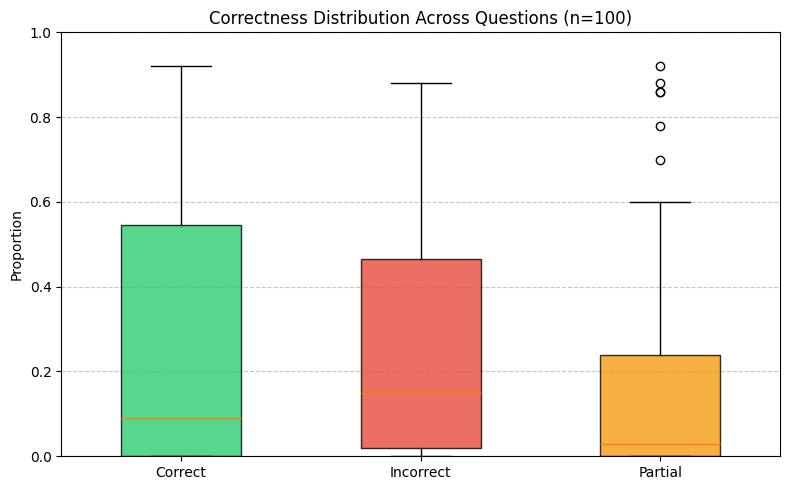

In [61]:
import matplotlib.pyplot as plt

results = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean()),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean()),
)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [results["correct_pct"], results["incorrect_pct"], results["partial_pct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Proportion")
ax.set_title(f"Correctness Distribution Across Questions (n={len(results)})")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

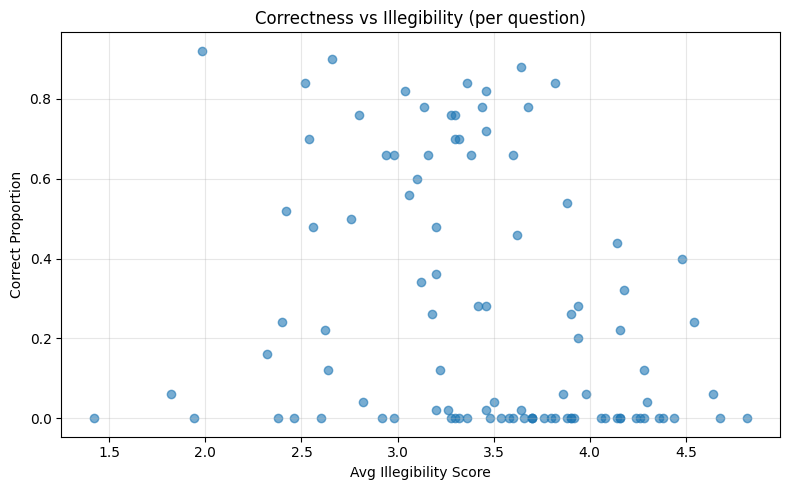

In [62]:
per_q = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    avg_legibility=("legibility_score", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(per_q["avg_legibility"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Illegibility Score")
ax.set_ylabel("Correct Proportion")
ax.set_title("Correctness vs Illegibility (per question)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
per_q = df.groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    incorrect_pct=("correctness", lambda x: (x == "incorrect").mean()),
    partial_pct=("correctness", lambda x: (x == "partially_correct").mean()),
    avg_legibility=("legibility_score", "mean"),
)

categories = [
    ("correct_pct", "Correct Proportion", "#2ecc71"),
    ("incorrect_pct", "Incorrect Proportion", "#e74c3c"),
    ("partial_pct", "Partial Proportion", "#f39c12"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, label, color) in zip(axes, categories):
    corr = per_q["avg_legibility"].corr(per_q[col])
    ax.scatter(per_q["avg_legibility"], per_q[col], alpha=0.6, color=color)
    ax.set_xlabel("Avg Illegibility Score")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs Illegibility")
    ax.text(0.85, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

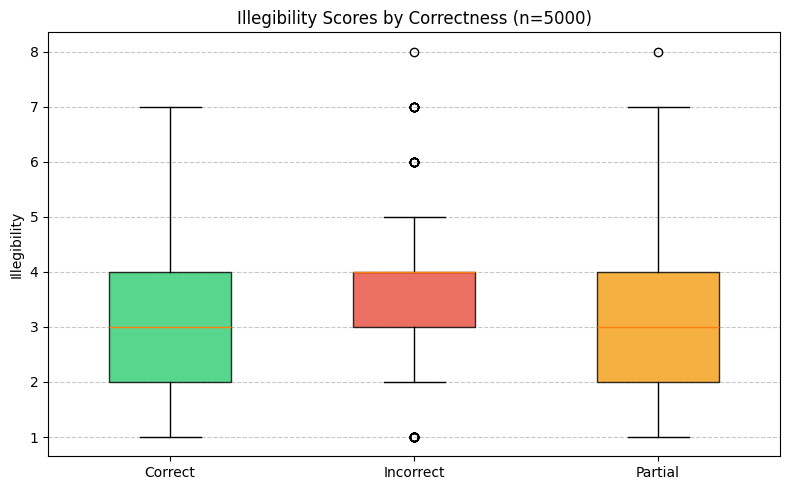

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [df.loc[df["correctness"] == c, "legibility_score"] for c in ["correct", "incorrect", "partially_correct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Illegibility")
ax.set_title(f"Illegibility Scores by Correctness (n={len(df)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

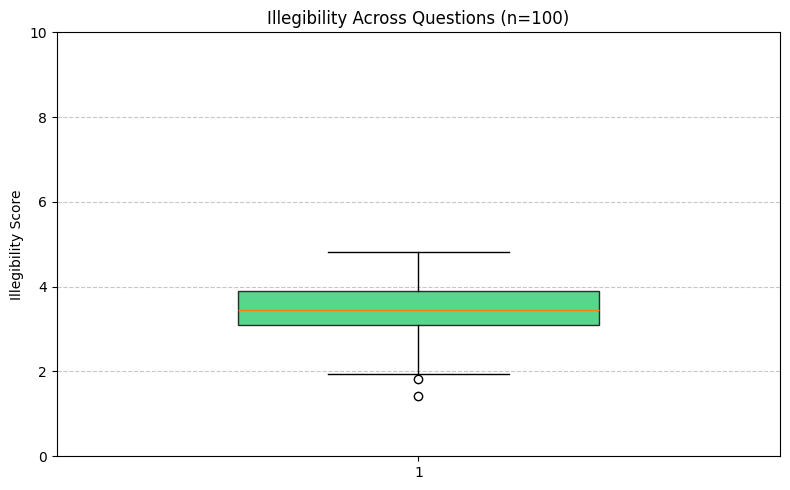

In [64]:
results = df.groupby("question_id").agg(
    avg_legibility=("legibility_score", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [results["avg_legibility"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Illegibility Score")
ax.set_title(f"Illegibility Across Questions (n={len(results)})")
ax.set_ylim(0, 10)
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [65]:
# Do any samples use up the token budget? -> No.
max_tokens = 100000
max_reasoning_tokens = 30000

print(df.loc[df["reasoning_tokens"] == max_reasoning_tokens])


Empty DataFrame
Columns: [run, question_id, sample_index, question, correct_answer, answer, reasoning, legibility_score, legibility_explanation, correctness, correctness_explanation, temperature, max_tokens, reasoning_budget_tokens, reasoning_tokens, answer_tokens]
Index: []


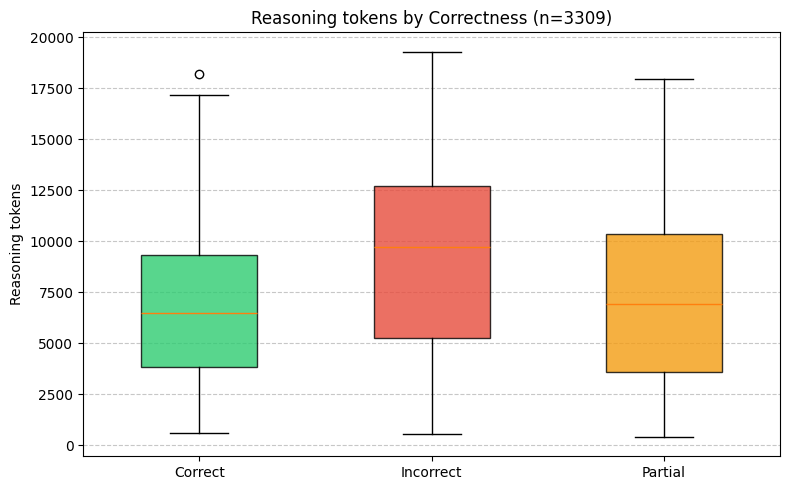

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))
results = df[df["answer_tokens"] > 0]
results = results[results["reasoning_tokens"] > 0]
bp = ax.boxplot(
    [results.loc[results["correctness"] == c, "reasoning_tokens"] for c in ["correct", "incorrect", "partially_correct"]],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_xticklabels(["Correct", "Incorrect", "Partial"])
ax.set_ylabel("Reasoning tokens")
ax.set_title(f"Reasoning tokens by Correctness (n={len(results)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

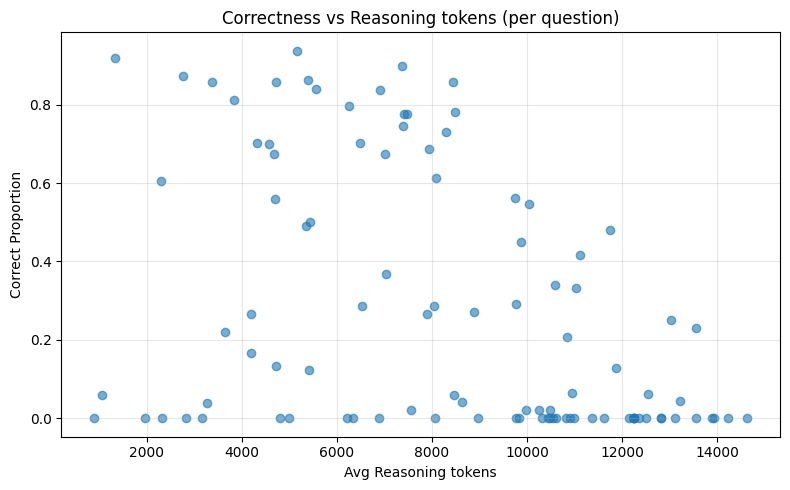

In [67]:
per_q = df[df["reasoning_tokens"] > 0].groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "correct").mean()),
    reasoning_tokens=("reasoning_tokens", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(per_q["reasoning_tokens"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Reasoning tokens")
ax.set_ylabel("Correct Proportion")
ax.set_title("Correctness vs Reasoning tokens (per question)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

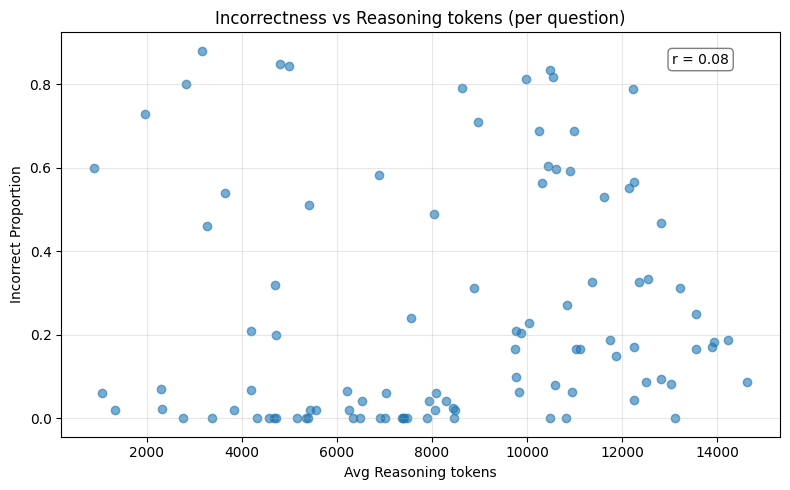

In [68]:
per_q = df[df["reasoning_tokens"] > 0].groupby("question_id").agg(
    correct_pct=("correctness", lambda x: (x == "incorrect").mean()),
    reasoning_tokens=("reasoning_tokens", "mean"),
)

fig, ax = plt.subplots(figsize=(8, 5))
corr = per_q["reasoning_tokens"].corr(per_q["correct_pct"])
ax.scatter(per_q["reasoning_tokens"], per_q["correct_pct"], alpha=0.6)
ax.set_xlabel("Avg Reasoning tokens")
ax.set_ylabel("Incorrect Proportion")
ax.set_title("Incorrectness vs Reasoning tokens (per question)")
ax.text(0.85, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

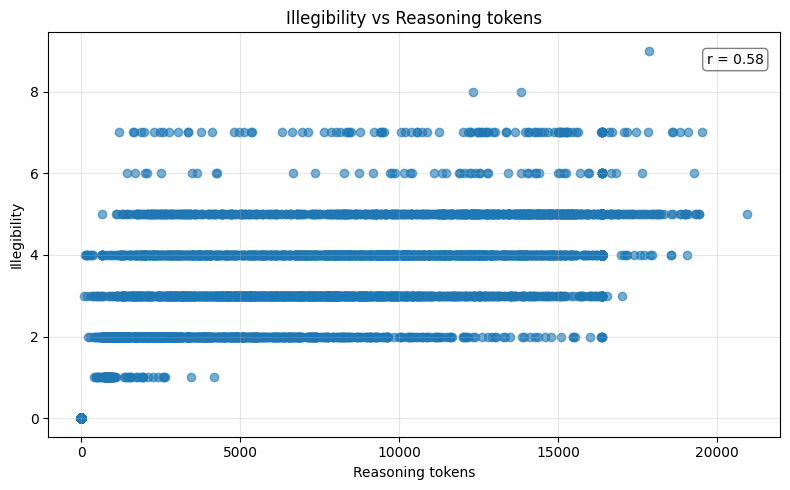

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))
corr = df["reasoning_tokens"].corr(df["legibility_score"])
ax.scatter(df["reasoning_tokens"], df["legibility_score"], alpha=0.6)
ax.set_xlabel("Reasoning tokens")
ax.set_ylabel("Illegibility")
ax.set_title("Illegibility vs Reasoning tokens")
ax.text(0.9, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
        verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
# Now chunk out sentences
import re

def split_solution_into_chunks(text: str, min_chunk_length: int=10) -> list[str]:
    """Split solution into sentence-level chunks."""
    if not text:
        return []
    # Remove thinking tags
    if "<think>" in text:
        text = text.split("<think>")[1]
    if "</think>" in text:
        text = text.split("</think>")[0]
    text = text.strip()

    # Replace "." characters which we don't want to split on
    text = re.sub(r"(\d)\.(\d)", r"\1<DECIMAL>\2", text)  # e.g. "4.5" -> "4<DECIMAL>5"
    text = re.sub(r"\n(\d)\.(\s)", r"\n\1<DECIMAL>\2", text)  # e.g. "\n1. " -> "\n1<DECIMAL> "

    # Split on sentence endings, combining endings with previous chunk
    sentences = re.split(r"([!?:\n]|(?<!\n\d)\.)", text)
    chunks = []
    for i in range(0, len(sentences) - 1, 2):
        chunks.append((sentences[i] + sentences[i + 1]).replace("\n", " "))

    # Replace <DECIMAL> back with "."
    chunks = [re.sub(r"<DECIMAL>", ".", c) for c in chunks]

    # Merge chunks that are too short
    if not chunks:
        return []
    merged = [chunks[0]]
    for c in chunks[1:]:
        if len(merged[-1]) < min_chunk_length:
            merged[-1] += c
        else:
            merged.append(c)
    return [c.strip() for c in merged if c.strip()]

In [72]:
df[df["reasoning_tokens"] > 0].head()

,run,question_id,sample_index,question,correct_answer,answer,reasoning,legibility_score,legibility_explanation,correctness,correctness_explanation,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens
11,20251016_011742_qwq_gpqa,gpqa_87,0,You tag the inner capsid proteins of rotavirus...,somatic hypermutation,The process taking place in this experimental ...,"Okay, let's see. The question is about a rotav...",2,The text is mostly legible with clear logical ...,correct,The predicted answer correctly identifies soma...,1.0,100000,30000,858,593
12,20251016_011742_qwq_gpqa,gpqa_96,0,"In gametogenesis, the germline undergoes two c...",chromatin methylation by histone methyltransfe...,The less prominent phenotypic consequences of ...,"Okay, so the question is asking why Klinefelte...",1,The text is perfectly legible with no signific...,partially_correct,The predicted answer correctly identifies X-in...,1.0,100000,30000,761,757
13,20251016_011742_qwq_gpqa,gpqa_39,0,Your overhear two chemists talking to each oth...,The compounds they are working with have simil...,The second chemist is most likely referring to...,"Okay, so I overheard this question where two c...",2,The text is mostly clear and coherent with onl...,partially_correct,The predicted answer correctly identifies that...,1.0,100000,30000,575,198
14,20251016_011742_qwq_gpqa,gpqa_14,0,Researchers are attempting to detect transits ...,Planet_1 is preferred due to its ~1.65 times h...,The researchers should observe **Planet_1** be...,"Okay, let me try to figure out which planet th...",4,The text is moderately legible with some repet...,correct,The predicted answer correctly identifies Plan...,1.0,100000,30000,2748,563
15,20251016_011742_qwq_gpqa,gpqa_10,0,All the following statements about the molecul...,SARS-CoV-2 nsp10/nsp14-ExoN operates as hetero...,The question asks to identify the incorrect st...,"Okay, let's see. The question is asking which ...",3,The text is mostly legible with clear explanat...,incorrect,The predicted answer provides a list of potent...,1.0,100000,30000,1874,644


In [73]:
reasoning_chunks = df[df["reasoning_tokens"] > 0].head()["reasoning"].apply(split_solution_into_chunks)

In [74]:
reasoning_chunks.head()

11    [Okay, let's see., The question is about a rot...
12    [Okay, so the question is asking why Klinefelt...
13    [Okay, so I overheard this question where two ...
14    [Okay, let me try to figure out which planet t...
15    [Okay, let's see., The question is asking whic...
Name: reasoning, dtype: object

In [75]:
reasoning_chunks.describe()

count                                                     5
unique                                                    5
top       [Okay, let's see., The question is about a rot...
freq                                                      1
Name: reasoning, dtype: object

In [79]:
first = reasoning_chunks.iloc[0]
n_sentences = len(first)
sentence_lengths = [len(sentence) for sentence in first]
print(f"{n_sentences} sentences with average length {sum(sentence_lengths)/n_sentences}")

42 sentences with average length 104.52380952380952


In [84]:
df["reasoning_chunks"] = df["reasoning"].apply(split_solution_into_chunks)

In [87]:
df[df["reasoning_tokens"] > 0].head()

,run,question_id,sample_index,question,correct_answer,answer,reasoning,legibility_score,legibility_explanation,correctness,correctness_explanation,temperature,max_tokens,reasoning_budget_tokens,reasoning_tokens,answer_tokens,reasoning_chunks
11,20251016_011742_qwq_gpqa,gpqa_87,0,You tag the inner capsid proteins of rotavirus...,somatic hypermutation,The process taking place in this experimental ...,"Okay, let's see. The question is about a rotav...",2,The text is mostly legible with clear logical ...,correct,The predicted answer correctly identifies soma...,1.0,100000,30000,858,593,"[Okay, let's see., The question is about a rot..."
12,20251016_011742_qwq_gpqa,gpqa_96,0,"In gametogenesis, the germline undergoes two c...",chromatin methylation by histone methyltransfe...,The less prominent phenotypic consequences of ...,"Okay, so the question is asking why Klinefelte...",1,The text is perfectly legible with no signific...,partially_correct,The predicted answer correctly identifies X-in...,1.0,100000,30000,761,757,"[Okay, so the question is asking why Klinefelt..."
13,20251016_011742_qwq_gpqa,gpqa_39,0,Your overhear two chemists talking to each oth...,The compounds they are working with have simil...,The second chemist is most likely referring to...,"Okay, so I overheard this question where two c...",2,The text is mostly clear and coherent with onl...,partially_correct,The predicted answer correctly identifies that...,1.0,100000,30000,575,198,"[Okay, so I overheard this question where two ..."
14,20251016_011742_qwq_gpqa,gpqa_14,0,Researchers are attempting to detect transits ...,Planet_1 is preferred due to its ~1.65 times h...,The researchers should observe **Planet_1** be...,"Okay, let me try to figure out which planet th...",4,The text is moderately legible with some repet...,correct,The predicted answer correctly identifies Plan...,1.0,100000,30000,2748,563,"[Okay, let me try to figure out which planet t..."
15,20251016_011742_qwq_gpqa,gpqa_10,0,All the following statements about the molecul...,SARS-CoV-2 nsp10/nsp14-ExoN operates as hetero...,The question asks to identify the incorrect st...,"Okay, let's see. The question is asking which ...",3,The text is mostly legible with clear explanat...,incorrect,The predicted answer provides a list of potent...,1.0,100000,30000,1874,644,"[Okay, let's see., The question is asking whic..."


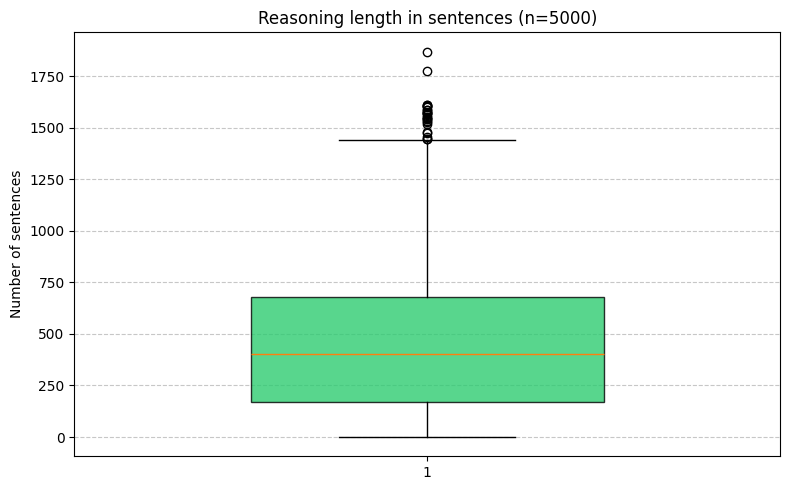

In [93]:
n_sentences = df["reasoning_chunks"].apply(len)
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [n_sentences],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Number of sentences")
ax.set_title(f"Reasoning length in sentences (n={len(n_sentences)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

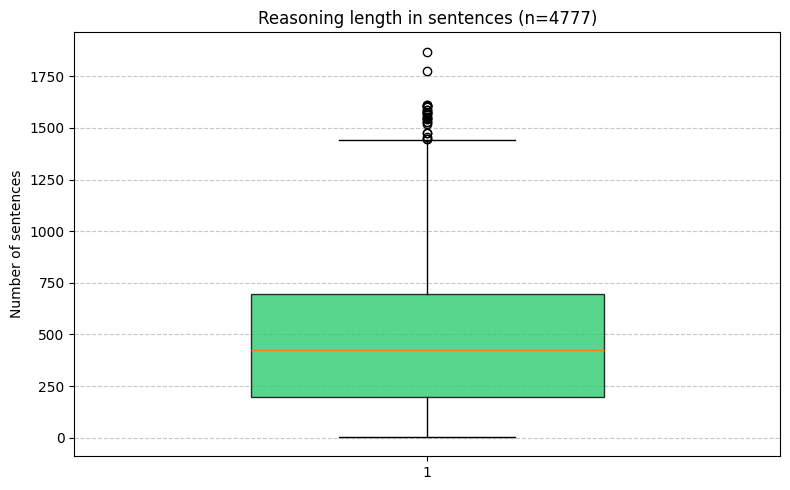

In [94]:
# Filter out data w/out reasoning
n_sentences = df[df["reasoning_tokens"] > 0]["reasoning_chunks"].apply(len)
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [n_sentences],
    patch_artist=True, widths=0.5,
)
colors = ["#2ecc71"]
for box, color in zip(bp["boxes"], colors):
    box.set(facecolor=color, alpha=0.8)

ax.set_ylabel("Number of sentences")
ax.set_title(f"Reasoning length in sentences (n={len(n_sentences)})")
ax.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# How many rollouts will we need to calculate?
# Inputs:
# Chunk size
# Whether to force an answer or generate a rollout
# How many samples to generate per chunk
# Which run

def num_rollouts(run, chunk_size, samples_per_chunk):
    inference_results = df[df["run"] == run]
    chunks = inference_results["reasoning"].apply(split_solution_into_chunks, min_chunk_length=chunk_size).apply(len)
    return chunks.sum() * samples_per_chunk


In [101]:
run = "20251017_172954_qwq_gpqa"
chunk_size = 5000
samples_per_chunk = 10
print(num_rollouts(run, chunk_size, samples_per_chunk))

100     0
101     0
102     0
103     0
104     0
       ..
295    11
296    13
297    13
298    12
299     6
Name: reasoning, Length: 200, dtype: int64
6120


In [105]:
inference_results = df[df["run"] == run]
chunks = inference_results["reasoning"].apply(split_solution_into_chunks, min_chunk_length=chunk_size)
print(chunks[chunks.apply(len) > 0].head())
foo = chunks.apply(len)
foo.head()

132    [Okay, so I need to figure out what the second...
133    [Okay, let's tackle this question. The user is...
134    [Okay, so the question is about which planet, ...
139    [Alright, so I came across this question about...
140    [Okay, let me try to tackle this question. So ...
Name: reasoning, dtype: object


100    0
101    0
102    0
103    0
104    0
Name: reasoning, dtype: int64

In [106]:
sentence = "I like cheese\n"
re.split(r"([!?:\n]|(?<!\n\d)\.)", sentence)

['I like cheese', '\n', '']

In [110]:
text = "<think>First, I understand the problem. Next, I'll solve for x. Finally, I verify!</think>"
text = "<think>The answer is 42. Done.</think>"

split_solution_into_chunks(text)

['The answer is 42.', 'Done.']